# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Marco Antonio Delgado Pérez

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
import pandas as pd 

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np 

In [4]:
import seaborn as sns

In [5]:
#Cargar el dataset
df = pd.read_csv("ventas-por-factura.csv")

In [6]:
df

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"
...,...,...,...,...,...,...
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"


In [7]:
df.shape

(25953, 6)

In [8]:
df.head(5)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [9]:
df.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [10]:
df.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [11]:
#Limpieza de datos
df.duplicated().sum()

np.int64(10)

In [12]:
# Eliminar registros duplicados
df = df.drop_duplicates().copy()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25943 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25943 non-null  object 
 1   Fecha de factura  25943 non-null  object 
 2   ID Cliente        22221 non-null  float64
 3   País              25943 non-null  object 
 4   Cantidad          25943 non-null  int64  
 5   Monto             25943 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


In [15]:
df.dtypes

N° de factura        object
Fecha de factura     object
ID Cliente          float64
País                 object
Cantidad              int64
Monto                object
dtype: object

In [16]:
# Transformación de tipo de datos: 'Monto' a float
df['Monto'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)

In [17]:
# Transformación de tipo de datos: 'Fecha de factura' a datetime
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

In [19]:
df.dtypes

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                 float64
País                        object
Cantidad                     int64
Monto                      float64
dtype: object

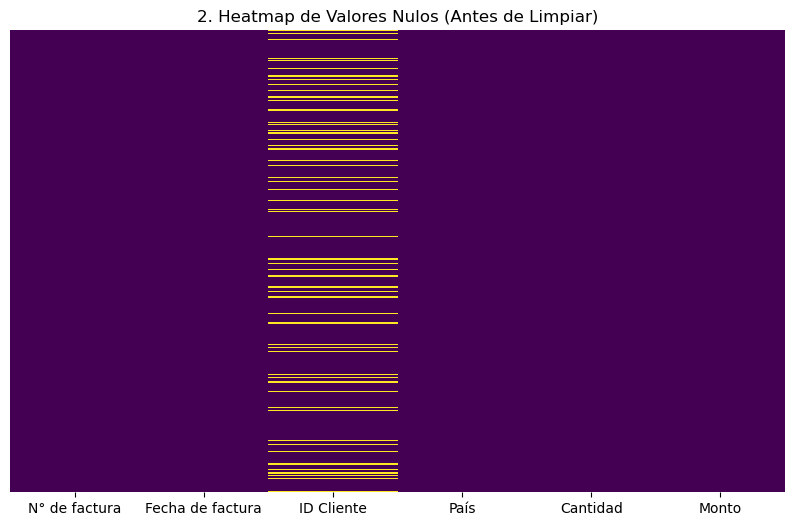

In [18]:
# Gráfica 1: Heatmap de valores nulos 
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('2. Heatmap de Valores Nulos (Antes de Limpiar)')
plt.show()

In [20]:
# Tratamiento de valores nulos
df['ID Cliente'] = df['ID Cliente'].fillna('Desconocido')

In [21]:
# Tratamiento de Outliers y Cancelaciones (Remover negativos y N° de factura con 'C')
df_clean = df[(df['Cantidad'] > 0) & (df['Monto'] > 0)].copy()
df_clean = df_clean[~df_clean['N° de factura'].astype(str).str.startswith('C')]

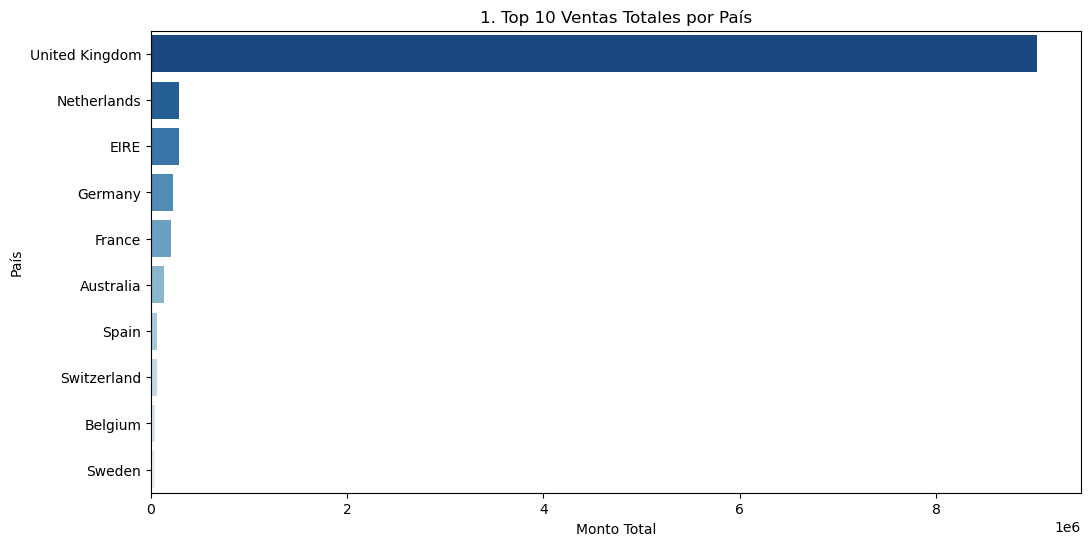

In [23]:
# Gráfica 2: Ventas por país (Usando el df_clean)
plt.figure(figsize=(12, 6))
ventas_pais = df_clean.groupby('País')['Monto'].sum().sort_values(ascending=False).head(10) # Top 10 para mejor visualización
sns.barplot(x=ventas_pais.values, y=ventas_pais.index, hue=ventas_pais.index, palette='Blues_r', legend=False)
plt.title('1. Top 10 Ventas Totales por País')
plt.xlabel('Monto Total')
plt.ylabel('País')
plt.show()

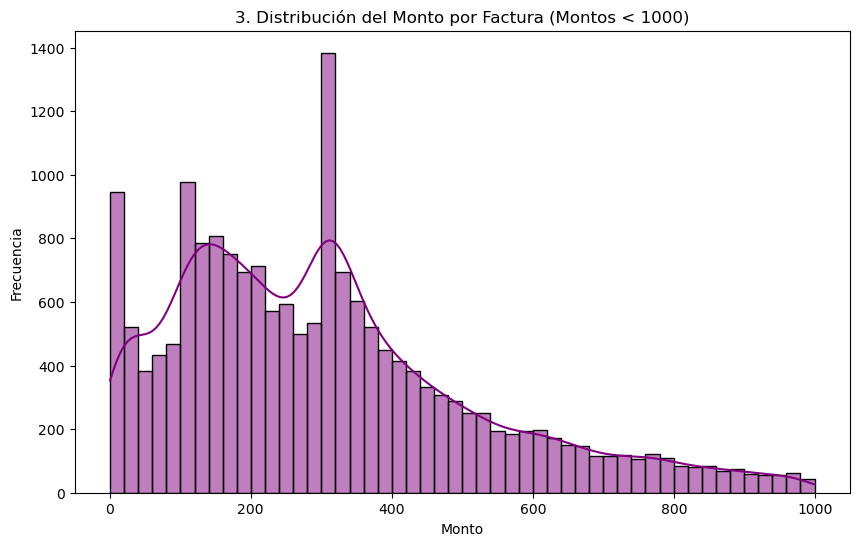

In [24]:
# Gráfica 3: Distribución del monto (Usando el df_clean y limitando el rango para evitar distorsión visual)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean[df_clean['Monto'] < 1000]['Monto'], bins=50, kde=True, color='purple')
plt.title('3. Distribución del Monto por Factura (Montos < 1000)')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

# Justificación de Limpieza y Transformación

1. Eliminación de duplicados: Evita métricas infladas. Previene que los reportes muestren ventas o volúmenes de compra irreales.
2. Transformación de tipos de datos: * Monto a numérico: Habilita operaciones matemáticas (sumas, promedios).
3. Fecha a datetime: Permite el análisis temporal (tendencias por mes/día).
4. Tratamiento de nulos (ID Cliente): Imputar como "Desconocido" salva el registro económico. Permite sumar el ingreso de la venta sin atribuirlo a un cliente falso.
5. Eliminación de Outliers (Cancelaciones): Filtrar negativos y facturas tipo "C" elimina sesgos negativos. Asegura que el modelo solo analice ventas efectivas.

# El Principio GIGO (Garbage In, Garbage Out)

Concepto Clave: "Basura entra, basura sale". La precisión de cualquier análisis o modelo depende 100% de la calidad de los datos iniciales.
1. Impacto en Análisis de Datos: * Problema: Datos sucios generan tableros y reportes falsos.
2. Consecuencia: Malas decisiones de negocio basadas en realidades alteradas.
3. Impacto en Machine Learning (ML):

    1. Problema: Los algoritmos aprenden patrones de los datos; si hay errores (ruido), el modelo los aprende como reglas válidas.
    
    2. Consecuencia: Predicciones inexactas o inútiles (ej. pronosticar ventas usando devoluciones).
  
# Conclusión

Limpiar los datos es el cimiento para asegurar que "Calidad entre, Calidad salga".